In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import warnings
from pathlib import Path
from aquarel import load_theme

theme = load_theme("minimal_light")
theme.apply()
theme.apply_transforms()
import matplotlib as mpl
mpl.rcParams['axes.spines.left'] = True
mpl.rcParams['axes.spines.right'] = False
mpl.rcParams['axes.spines.top'] = False
mpl.rcParams['axes.spines.bottom'] = True
mpl.rcParams['axes.edgecolor'] = 'grey'

<Figure size 640x480 with 0 Axes>

In [2]:
FIGURE_DATA = Path("../figure_data")
bins = pd.read_csv(FIGURE_DATA / 'pr_auc_bins.csv')

# Rename TreeWAS Terminal -> TreeWAS for display; drop other TreeWAS variants
bins['method'] = bins['method'].replace({'TreeWAS Terminal': 'TreeWAS'})
bins = bins[~bins['method'].isin(['TreeWAS Subsequent', 'TreeWAS Simultaneous'])]

In [3]:
METHOD_ORDER = ['SimPhyNI', 'FaST-LMM', 'TreeWAS', 'Pagel', 'Scoary', 'Coinfinder', "Fisher's"]

# Explicit color dict — stable regardless of which methods appear in a given figure.
# Colors match the tab10 palette assigned by position in METHOD_ORDER so that
# every figure in this repo uses the same method → color mapping.
method_colors = {
    'SimPhyNI':   '#1f77b4',  # tab10[0] blue
    'FaST-LMM':   '#ff7f0e',  # tab10[1] orange
    'TreeWAS':    '#2ca02c',  # tab10[2] green
    'Pagel':      '#d62728',  # tab10[3] red
    'Scoary':     '#9467bd',  # tab10[4] purple
    'Coinfinder': '#8c564b',  # tab10[5] brown
    "Fisher's":  '#e377c2',  # tab10[6] pink
    # "Fisher's":   '#7f7f7f',  # tab10[7] gray
}

In [4]:
def _bin_means(sub, col):
    """Aggregate per d_bin_raw: mean ± SE across trees/effect_sizes."""
    g = (sub.groupby('d_bin_raw', observed=True)[col]
           .agg(['mean', 'std', 'count'])
           .rename(columns={'mean': 'rate', 'std': 'std', 'count': 'n'}))
    g['mid']   = sub.groupby('d_bin_raw', observed=True)['d_bin_mid'].mean()
    g['ci_lo'] = g['rate'] - 1.96 * g['std'] / np.sqrt(g['n'])
    g['ci_hi'] = g['rate'] + 1.96 * g['std'] / np.sqrt(g['n'])
    return g.dropna(subset=['mid'])


def make_panel(df, col, mod_c, d_mean, ax, ylabel, title):
    """Line plot with error bars; dashed OLS fit overlay if mod_c provided."""
    try:
        df['d_bin_raw'] = pd.qcut(df['d_bin_mid'], q=20, duplicates='drop')
    except ValueError:
        df['d_bin_raw'] = pd.cut(df['d_bin_mid'], bins=20)

    d_range = np.linspace(df['d_bin_mid'].quantile(0.02),
                          df['d_bin_mid'].quantile(0.98), 200)

    for method in METHOD_ORDER:
        sub = df[df['method'] == method]
        if sub.empty:
            continue
        g = _bin_means(sub, col)
        if g.empty:
            continue
        color = method_colors[method]
        ax.errorbar(
            g['mid'], g['rate'],
            yerr=[np.clip(g['rate'] - g['ci_lo'], 0, None),
                  np.clip(g['ci_hi'] - g['rate'], 0, None)],
            label=method, color=color, marker='o',
            linewidth=1.4, markersize=4, capsize=2, alpha=0.85,
        )
        if mod_c is not None:
            pred_df = pd.DataFrame({
                'd_mid_c':    d_range - d_mean,
                'method':     method,
                'es_input_c': 0.0,
            })
            try:
                y_pred = mod_c.predict(pred_df)
                ax.plot(d_range, y_pred, '--', color=color,
                        linewidth=1.0, alpha=0.6)
            except Exception:
                pass

    ax.axvline(0.0, color='grey', linestyle=':', linewidth=0.8, zorder=0)
    ax.axvline(1.0, color='grey', linestyle=':', linewidth=0.8, zorder=0)
    ax.set_xlabel('D statistic')
    ax.set_ylabel(ylabel)
    ax.set_ylim(-0.02, 1.05)
    ax.set_title(title, style='italic')

/Users/jpeyemi/opt/miniconda3/envs/simphyni/lib/python3.11/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding
/Users/jpeyemi/opt/miniconda3/envs/simphyni/lib/python3.11/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding
/Users/jpeyemi/opt/miniconda3/envs/simphyni/lib/python3.11/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding
/Users/jpeyemi/opt/miniconda3/envs/simphyni/lib/python3.11/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding
/Users/jpeyemi/opt/miniconda3/envs/simphyni/lib/python3.11/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  va

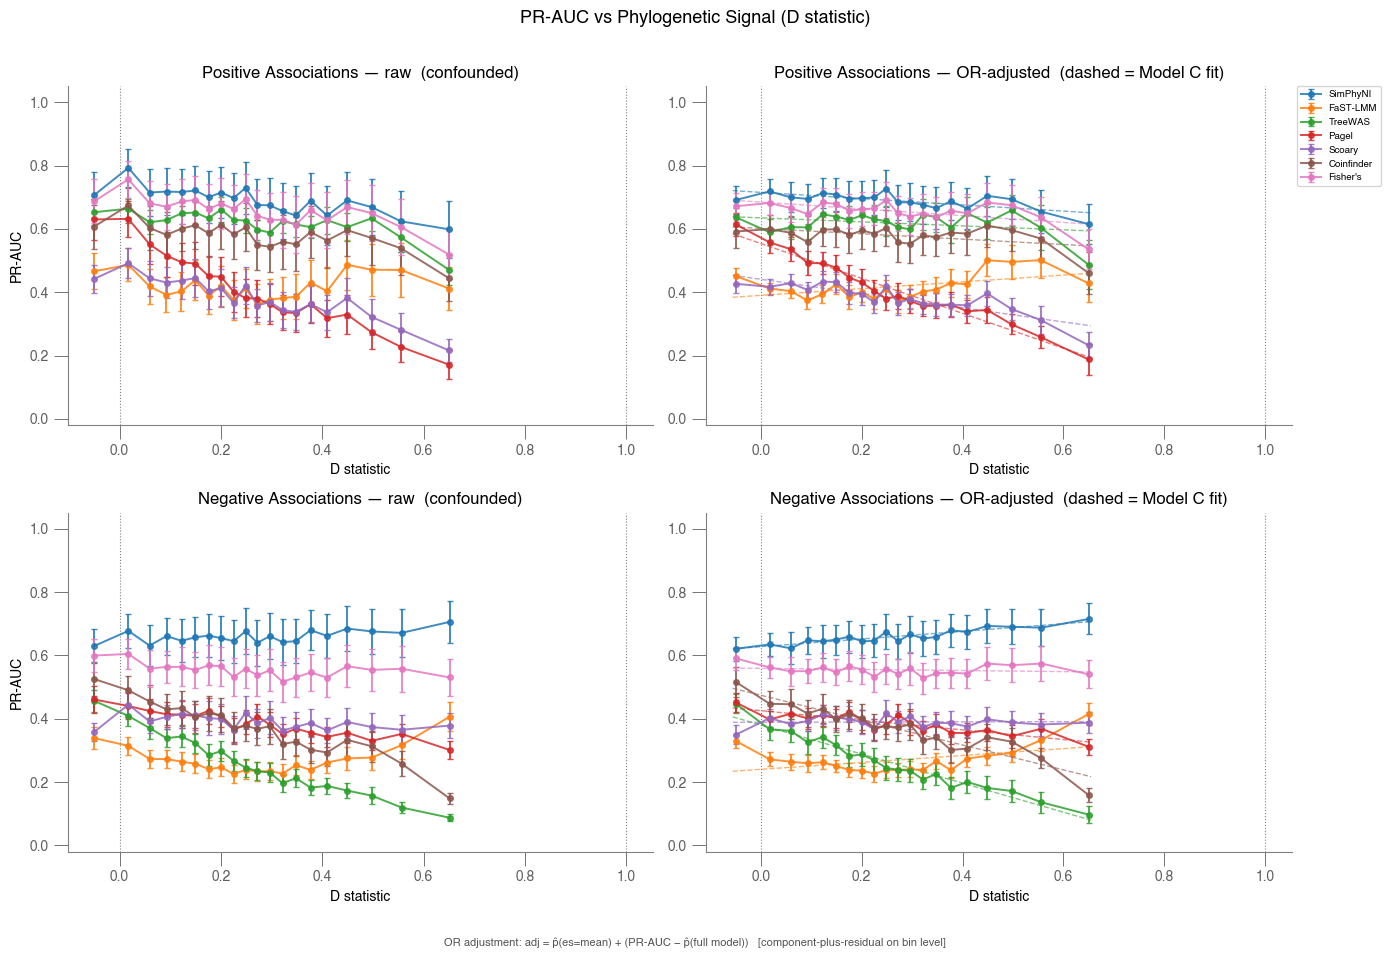

In [5]:
### Figure — PR-AUC vs D-statistic
# 2 rows (direction=+1, direction=-1) × 2 cols (raw, OR-corrected)

_REF    = "Treatment('SimPhyNI')"
FORMULA = f"prauc ~ d_mid_c * C(method, {_REF}) + es_input_c"

direction_specs = [
    (1,  'Positive Associations'),
    (-1, 'Negative Associations'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('PR-AUC vs Phylogenetic Signal (D statistic)', fontsize=13, y=1.01)

for row, (dir_val, dir_label) in enumerate(direction_specs):
    sub = bins[bins['direction'] == dir_val].copy()

    # Set SimPhyNI as reference category
    cats = ['SimPhyNI'] + [m for m in METHOD_ORDER
                           if m != 'SimPhyNI' and m in sub['method'].unique()]
    sub['method'] = pd.Categorical(sub['method'], categories=cats, ordered=False)

    # Re-centre covariates within this direction
    d_mean  = sub['d_bin_mid'].mean()
    es_mean = sub['es_input'].mean()
    sub['d_mid_c']    = sub['d_bin_mid'] - d_mean
    sub['es_input_c'] = sub['es_input']  - es_mean

    # Fit Model C
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        mod_c = smf.ols(FORMULA, data=sub).fit(disp=False)

    # OR adjustment (component-plus-residual on bin level)
    p_hat = mod_c.predict(sub[['d_mid_c', 'method', 'es_input_c']])
    df0   = sub.copy(); df0['es_input_c'] = 0.0
    p_adj = mod_c.predict(df0[['d_mid_c', 'method', 'es_input_c']])
    sub['prauc_adj'] = p_adj.values + (sub['prauc'].values - p_hat.values)

    make_panel(sub.copy(), 'prauc',
               None, d_mean, axes[row, 0],
               'PR-AUC', f'{dir_label} — raw  (confounded)')
    make_panel(sub.copy(), 'prauc_adj',
               mod_c, d_mean, axes[row, 1],
               '', f'{dir_label} — OR-adjusted  (dashed = Model C fit)')

axes[0, 1].legend(fontsize=7, bbox_to_anchor=(1.01, 1),
                  loc='upper left', borderaxespad=0)
fig.text(0.5, -0.03,
         'OR adjustment: adj = p̂(es=mean) + (PR-AUC − p̂(full model))   '
         '[component-plus-residual on bin level]',
         ha='center', fontsize=8, color='#555555')

plt.tight_layout()
plt.savefig('fig.svg', format='svg')
plt.show()

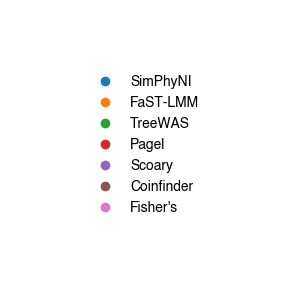

In [6]:
### Legend
fig_leg, ax_leg = plt.subplots(figsize=(3, 3))
ax_leg.axis('off')
handles = [plt.Line2D([0], [0], color=method_colors[m], lw=0,
                      marker='o', markersize=6) for m in METHOD_ORDER]
ax_leg.legend(handles, METHOD_ORDER, loc='center', frameon=False)
plt.tight_layout()
plt.savefig('figleg.svg', format='svg')
plt.show()